In [34]:
import matplotlib.pyplot as plt
import numpy as np
from galpy.util import conversion
import astropy.units as u
from galpy.potential import (
    MWPotential2014, 
    vcirc,
    evaluateDensities,
    mass,
    HernquistPotential,
    NFWPotential)
from galpy.orbit import Orbit
from galpy.util import conversion
import scipy
from scipy.optimize import minimize

ro, vo = 8.0 * u.kpc, 220.0 * u.km / u.s
R0 = 8.0 * u.kpc

MWPotential2014.turn_physical_on(ro=ro,vo=vo)

##Exercise 1

####1. and 3.

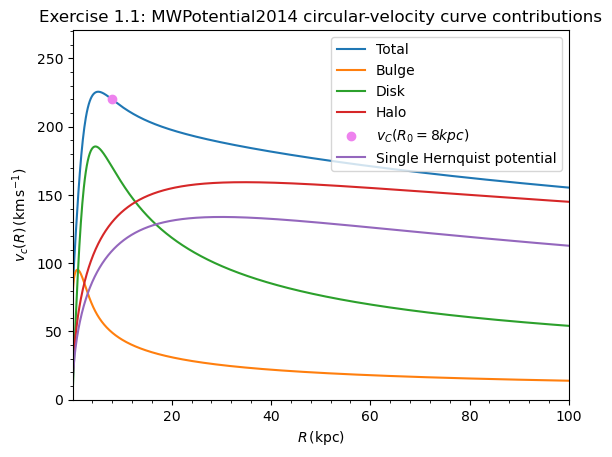

In [62]:
# get each component

bulge = MWPotential2014[0]
disk = MWPotential2014[1]
halo = MWPotential2014[2]

# get each component's vcirc plot in physical units
MWPotential2014.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    label="Total")

bulge.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    overplot=True,
    label="Bulge")

disk.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Disk")
  
halo.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Halo")
        

# find circular velocity at R0 = 8kpc
V0 = vcirc(MWPotential2014, R0.value/ro.value, ro=ro.value, vo=vo.value)
plt.scatter(R0.value, V0, label="$v_C(R_0=8kpc)$",color="violet",zorder=5)

# 3. Add single Hernquist

G = 4.30091e-6 
M  = 1e12
hp = HernquistPotential(
    amp=G * M / (vo.value**2 * ro.value),
    a=30/ro.value)

hp.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Single Hernquist potential"
    )

plt.legend()
plt.title("Exercise 1.1: MWPotential2014 circular-velocity curve contributions")

plt.show()

####2.

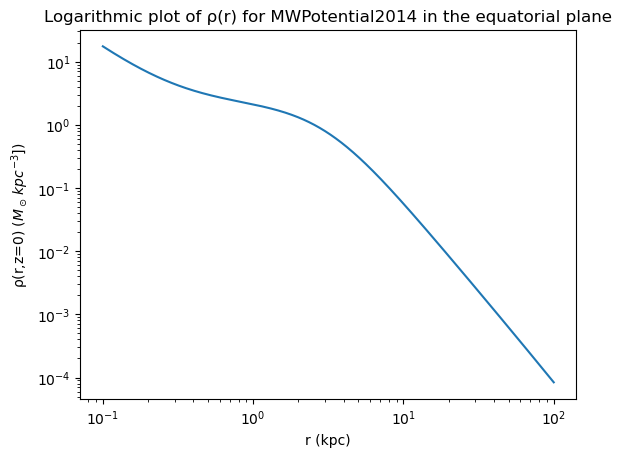

In [117]:
# Density plot
# make an r array from 10e-1 to 10e2 (0.1 to 100kpc)
r = np.logspace(-1,2,500)

# get r in galpy units
r_galpy = r/ro.value

rho = np.array([evaluateDensities(
    MWPotential2014,
    R,
    0.0,
    ro=ro.value,
    vo=vo.value,
    use_physical=True) 
    for R in r_galpy]) 
    
plt.loglog(r, rho)

plt.title("Logarithmic plot of ρ(r) for MWPotential2014 in the equatorial plane")
plt.xlabel("r (kpc)")
plt.ylabel("ρ(r,z=0) ($M_\odot\,{kpc}^{-3}]$)")

plt.show()

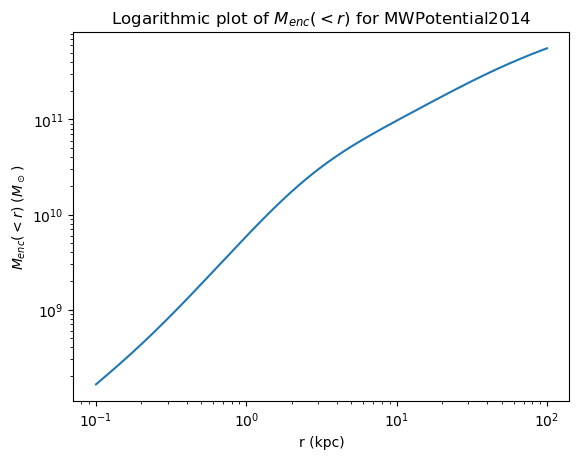

In [129]:
# Mass plot
menc = np.array([mass(
    MWPotential2014,
    R,
    ro=ro.value,
    vo=vo.value,
    use_physical=True,)
    for R in r_galpy])
    
plt.loglog(r, menc)

plt.title("Logarithmic plot of $M_{enc}(<r)$ for MWPotential2014")
plt.xlabel("r (kpc)")
plt.ylabel("$M_{enc}(<r)$ $(M_\odot\,{}$)")

plt.show()

##Exercise 2

####1.

In [119]:
o_sun = Orbit()
o_sun.turn_physical_on()

ts = np.linspace(0.0,5.0,10000) * u.Gyr
o_sun.integrate(ts,MWPotential2014)

####2.

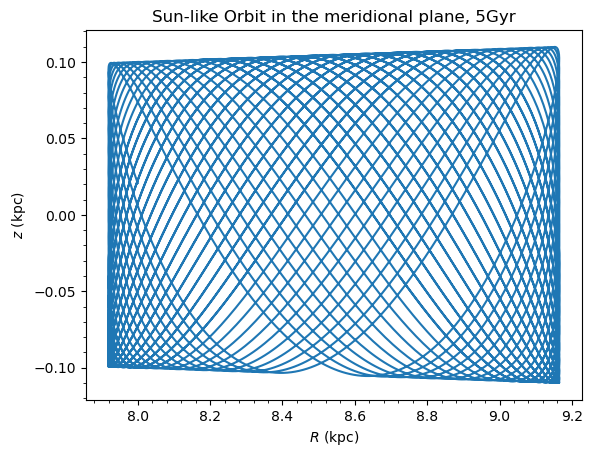

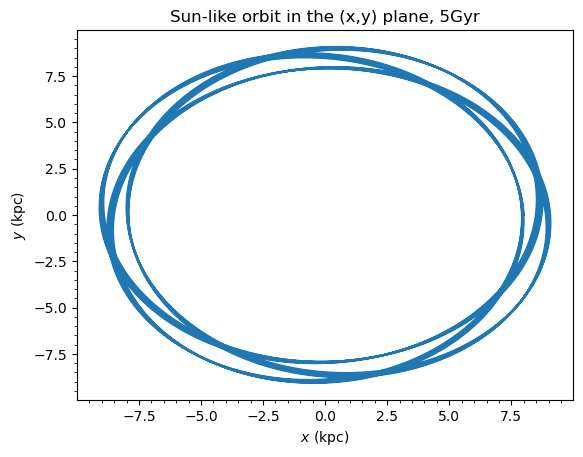

In [120]:
o_sun.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane, 5Gyr")
plt.show()

o_sun.plot(d1="x",d2="y")
plt.title("Sun-like orbit in the (x,y) plane, 5Gyr")
plt.show()

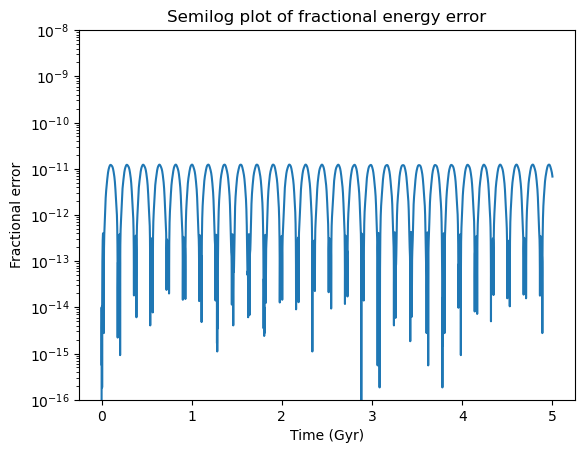

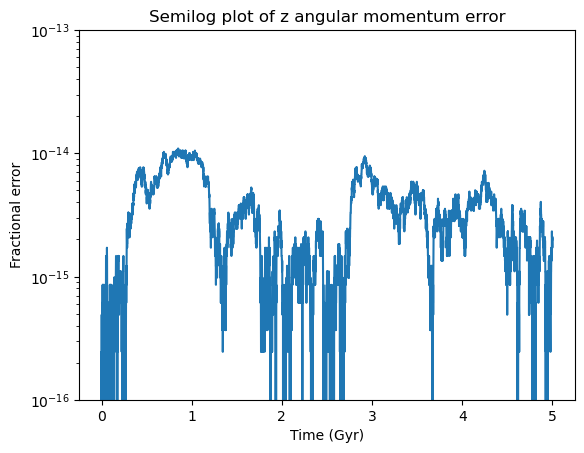

In [121]:
# find the energy and z angular momentum for all times
E = o_sun.E(ts, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts, use_physical=True)

# get the initial energy and angular momentum
E0 = E[0]
Lz0 = Lz[0]


# find fractional errors at each time

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts, E_error)
plt.title("Semilog plot of fractional energy error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-8)
plt.show()

plt.semilogy(ts, Lz_error)
plt.title("Semilog plot of z angular momentum error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-13)
plt.show()

These graphs show that the default integrator (symplec4_c) is has an error of around 1e-11 for energy and around 1e-14 for angular momentum (almost machine precision). The errors also seem to remain relatively stable over time.

C:\Users\mylan\AppData\Local\Temp\ipykernel_17584\1284994981.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-8)



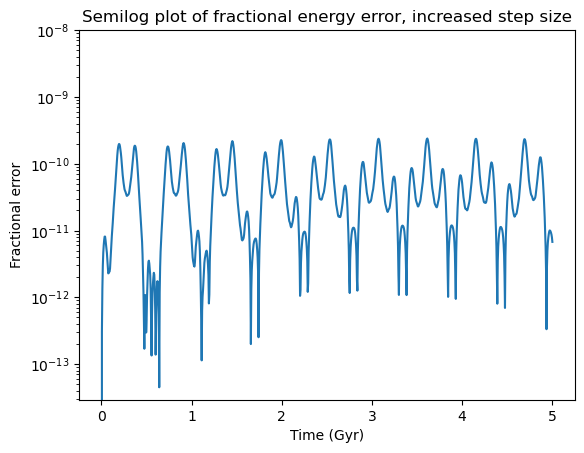

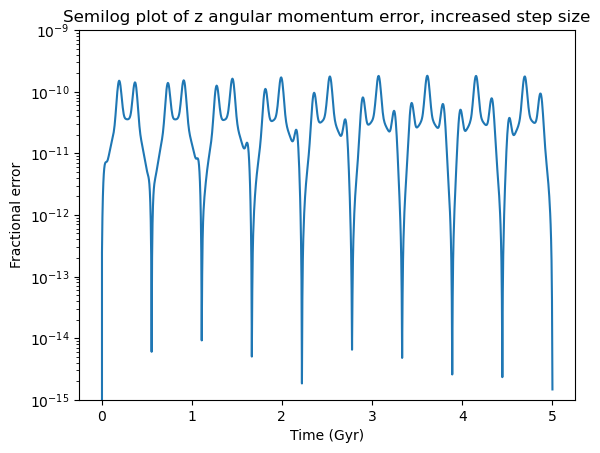

In [102]:
# changing the step size

ts_less = np.linspace(0.0,5.0,1000) * u.Gyr
o_sun.integrate(ts,MWPotential2014)

E = o_sun.E(ts_less, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts_less, use_physical=True)

E0 = E[0]
Lz0 = Lz[0]

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts_less, E_error)
plt.title("Semilog plot of fractional energy error, increased step size")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(0,1e-8)
plt.show()

plt.semilogy(ts_less, Lz_error)
plt.title("Semilog plot of z angular momentum error, increased step size")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-15,1e-9)
plt.show()

Increasing the step size increased the error for both energy and z angular momentum.

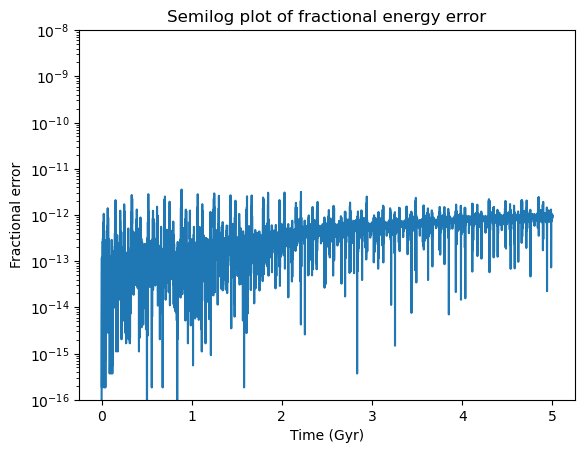

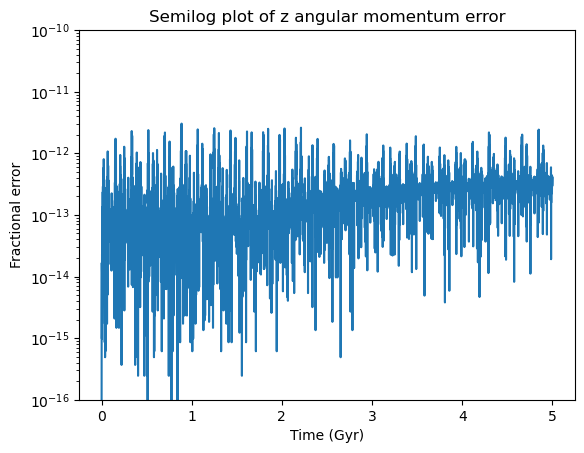

In [103]:
# trying different integration methods

o_sun.integrate(ts,MWPotential2014,method="dop853_c")

# find the energy and z angular momentum for all times
E = o_sun.E(ts, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts, use_physical=True)

# get the initial energy and angular momentum
E0 = E[0]
Lz0 = Lz[0]


# find fractional errors at each time

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts, E_error)
plt.title("Semilog plot of fractional energy error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-8)
plt.show()

plt.semilogy(ts, Lz_error)
plt.title("Semilog plot of z angular momentum error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-10)
plt.show()

The errors for the dop853_c method appear to trend upward over time. 

####3.

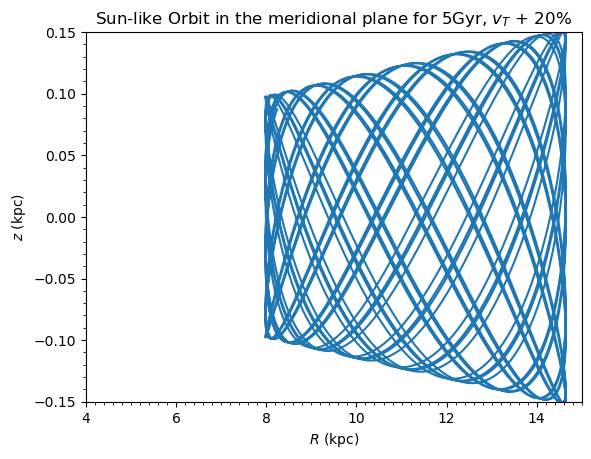

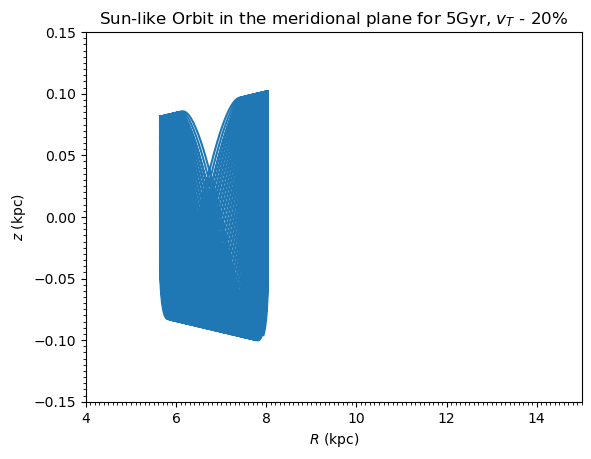

In [104]:
sun_R = 8.0 * u.kpc
sun_vR = -11.1 * u.km / u.s
sun_vT = 232.24 * u.km / u.s
sun_z = 0.0208 * u.kpc
sun_vz = 7.25 * u.km / u.s
sun_phi = 0.0 * u.rad

o_vTplus = Orbit([sun_R,
                  sun_vR,
                  1.2 * sun_vT,
                  sun_z,
                  sun_vz,
                  sun_phi])

o_vTplus.integrate(ts,MWPotential2014)
o_vTplus.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane for 5Gyr, $v_T$ + 20%")
plt.xlim(4,15)
plt.ylim(-0.15,0.15)
plt.show()

o_vTminus = Orbit([sun_R,
                  sun_vR,
                  0.8 * sun_vT,
                  sun_z,
                  sun_vz,
                  sun_phi])

o_vTminus.integrate(ts,MWPotential2014)
o_vTminus.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane for 5Gyr, $v_T$ - 20%")
plt.xlim(4,15)
plt.ylim(-0.15,0.15)
plt.show()


Increasing the initial vT by 20% produced a more radial orbit than lowering it, since the graph of the higher-vT orbit shows a much larger range of R values than the graph of the lower-vT orbit.

##Exercise 3

####1.

In [47]:
# Compute Menc(< r) for MWPotential2014 on a logarithmic grid from 0.1 to 300 kpc

r_grid = np.logspace(np.log10(0.1),np.log10(300),100) * u.kpc

menc_MW = np.array([mass(MWPotential2014, r) for r in r_grid])

####2.

In [48]:
# Find the best-fit (M,a)

def objective(params):
    # use logM and loga as params instead of M and a so they have a more similar scale
    logM, loga = params

    M = 10**logM * u.Msun
    a = 10**loga * u.kpc

    hq = HernquistPotential(amp=M,a=a)

    menc_HQ = mass(hq, r_grid)

    return np.sum((np.log10(menc_HQ) - np.log10(menc_MW))**2)

# set an initial guess (M = 1e12Msun, a = 10 kpc)
guess = [12.0, 1.0]

best_fit = minimize(objective,guess)

best_M = 10**best_fit.x[0]
best_a = 10**best_fit.x[1]

print(f"Best M is {best_M:.4e} Msun")
print(f"Best a is {best_a:.4f} kpc")

Best M is 1.0129e+12 Msun
Best a is 7.9383 kpc


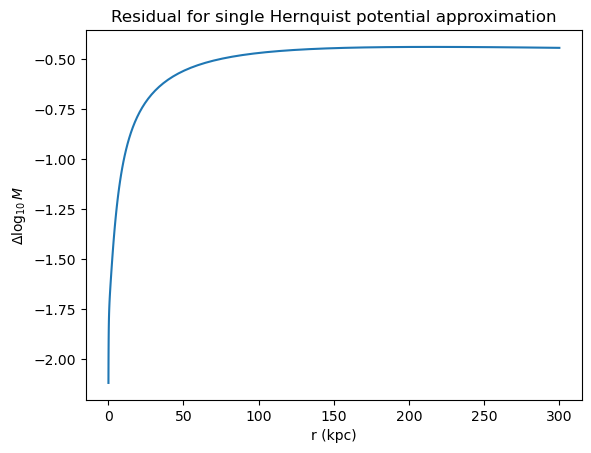

In [44]:
# Plot the residual

hq_best = HernquistPotential(amp=best_M, a=best_a)

menc_HQBest = mass(hq_best,r_grid)
 
residual = np.log10(menc_HQBest) - np.log10(menc_MW)

plt.plot(r_grid,residual)
plt.title("Residual for single Hernquist potential approximation")
plt.xlabel("r (kpc)")
plt.ylabel(r"$\Delta \log_{10} M$")

plt.show()

####3.


In [52]:
# Find the best-fit (M,a)

def objective(params):
    logM_hq, loga_hq, logM_nfw, loga_nfw = params

    # Hernquist (bulge)
    M_hq = 10**logM_hq * u.Msun
    a_hq = 10**loga_hq * u.kpc
    hq = HernquistPotential(amp=M_hq,a=a_hq)
    menc_hq = mass(hq, r_grid)

    # NFW (Halo)
    M_nfw = 10**logM_nfw * u.Msun
    a_nfw = 10**loga_nfw * u.kpc
    nfw = NFWPotential(amp=M_nfw,a=a_nfw)
    menc_nfw = mass(nfw,r_grid)

    menc_total = menc_hq + menc_nfw

    return np.sum((np.log10(menc_total) - np.log10(menc_MW))**2)

# set an initial guess (M = 1e12Msun, a = 10 kpc)
guess = [12.0, 1.0, 12.5, 1.2]

best_fit = minimize(objective,guess)

best_M_hq = 10**best_fit.x[0]
best_a_hq = 10**best_fit.x[1]
best_M_nfw = 10**best_fit.x[2]
best_a_nfw = 10**best_fit.x[3]

print(f"Best Hernquist M is {best_M_hq:.4e} Msun")
print(f"Best Hernquist a is {best_a_hq:.4f} kpc")
print(f"Best NFW M is {best_M_nfw:.4e} Msun")
print(f"Best NFW a is {best_a_nfw:.4f} kpc")

Best Hernquist M is 1.1161e+11 Msun
Best Hernquist a is 2.2579 kpc
Best NFW M is 3.6758e+11 Msun
Best NFW a is 11.4872 kpc


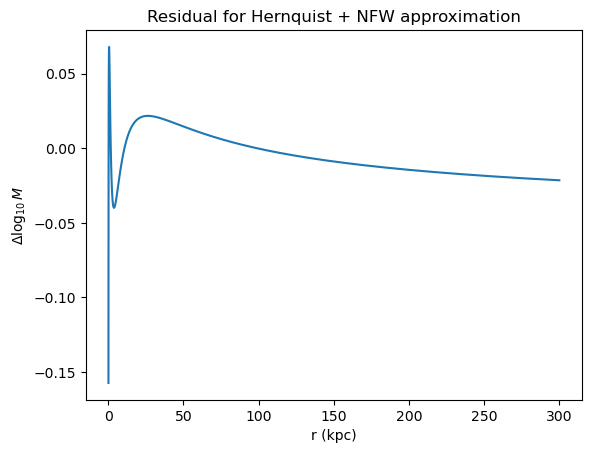

In [56]:
# Plot the residual

hq_component = HernquistPotential(amp=best_M_hq * u.Msun, a=best_a_hq * u.kpc)
menc_hq_component = mass(hq_component,r_grid)

nfw_component = NFWPotential(amp=best_M_nfw * u.Msun, a=best_a_nfw * u.kpc)
menc_nfw_component = mass(nfw_component, r_grid)

menc_total = menc_hq_component + menc_nfw_component
 
residual = np.log10(menc_total) - np.log10(menc_MW)

plt.plot(r_grid,residual)
plt.title("Residual for Hernquist + NFW approximation")
plt.xlabel("r (kpc)")
plt.ylabel(r"$\Delta \log_{10} M$")

plt.show()

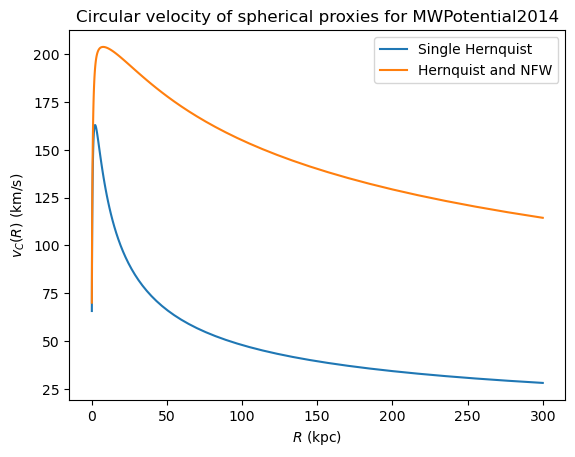

In [ ]:
hq_best = HernquistPotential(amp=best_M_hq * u.Msun, a=best_a_hq * u.kpc)
hq_vcirc = hq_best.vcirc(r_grid)
combined_potential = HernquistPotential(amp=best_M_hq * u.Msun, a=best_a_hq * u.kpc) \
    + NFWPotential(amp=best_M_nfw * u.Msun, a=best_a_nfw * u.kpc) 

combined_vcirc = combined_potential.vcirc(r_grid)

plt.plot(r_grid,hq_vcirc,label="Single Hernquist")
plt.plot(r_grid,combined_vcirc,label="Hernquist and NFW")
plt.xlabel("$R$ (kpc)")
plt.ylabel("$v_C(R)$ (km/s)")
plt.title("Circular velocity of spherical proxies for MWPotential2014")
plt.legend()
plt.show()


####4.